# Clustering
You will be asked to implement several functions.Team work is not allowed. 

Everybody implements his/her own code. Discussing issues with others is fine, sharing code with others is not.

If you use any code fragments found on the Internet, make sure you reference them properly.

In this exercise we will use unsupervised methods for clustering, in this case instead of having $X$ and $Y$ pairs at train time, we only have the input data $X$ at train time.

Let's work with 2 popular methods: K-means and Mean-shift.

## Dataset
To get familiar with the adavantages and disanvantages of the methods, we will use 3 different datasets:

1. toy data (2-dimensional blob data that is easy to visualize) for warm up.

2. 2d spiral data

3. country data including some socio-economic and health factors that can jointly determine the overall development of the country. We will use K-means and mean-shift methods on this dataset to make decision to choose the countries that are in the direst need of aid.


## Objectives
1. Learn to cluster data by kmeans and mean-shift approaches provided by scikit-learn library.
2. Understand how to evaluate them by intuition and metric values

## Contents:
1) scikit-learn K-means (3 points)

    1a) Toy dataset: blobs

    1b) Toy dataset: spirals
    

2) scikit-learn Mean-shift (3 points)

    2a) Toy dataset: blobs

    2b) Toy dataset: spirals
    

3) Country dataset (6 points)


4) Your own Mean-shift implementation (will be graded in lab 6 but this task is more difficult therefore you can already have a look at it this week)


## 1) sklearn K-means (3 points)

In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
%matplotlib inline 

### 1a) Toy dataset: blobs (1 point)
- Load toy dataset (blobs).

In [163]:
data_blobs = np.genfromtxt('Datasets/toy_data.csv', delimiter=',')
data_blobs

array([[11.40984207,  5.58112073],
       [-4.34272757, 11.08027991],
       [12.19338509,  4.41690355],
       ...,
       [12.55647723,  5.38065368],
       [-2.34860574, 11.21739209],
       [10.41592804, 11.62203767]])

- Use sklearn kmeans function (parameters by defalt) to cluster points.

In [164]:
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(data_blobs)

c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [165]:
kmeans.labels_

array([1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,

- Plot clustering results by ```plt.scatter()``` color the points according to the clusters from k-means

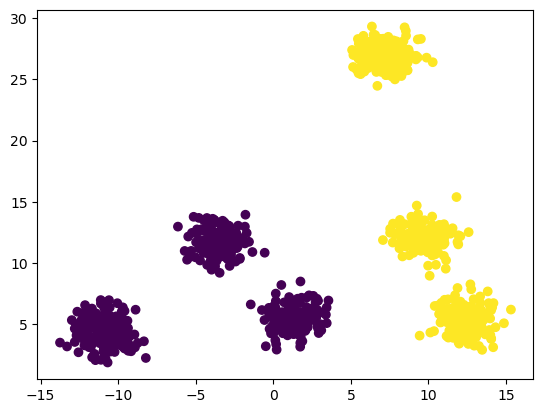

In [166]:
plt.scatter(data_blobs[:, 0], data_blobs[:, 1], c=kmeans.labels_.astype(float))

- Choosing the number of n_clusters without extra information is not trivial. For these blobs data, we don't have any labels. Which configurations do you think are be the best for this dataset? How many n_custers would you choose?
- Plot your results.

I would choose n_clusters to 6.

c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


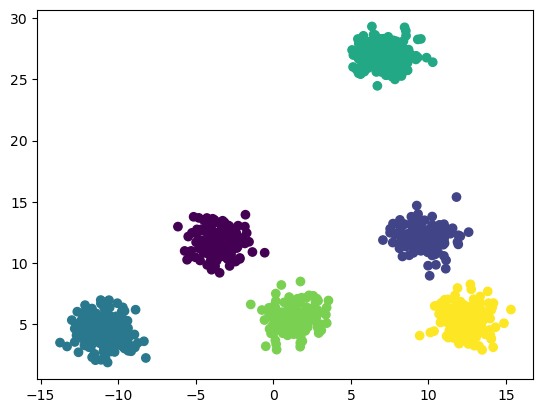

In [167]:
kmeans = KMeans(n_clusters=6, random_state=0, n_init="auto").fit(data_blobs)
plt.scatter(data_blobs[:, 0], data_blobs[:, 1], c=kmeans.labels_.astype(float))

### 1b) Spiral dataset (1 point)
- Try to use the KMeans to cluster the Spiral dataset.

In [168]:
# load data
spiral = np.load("Datasets/spiral.npz")['x']

In [169]:
spiral.shape

(312, 2)

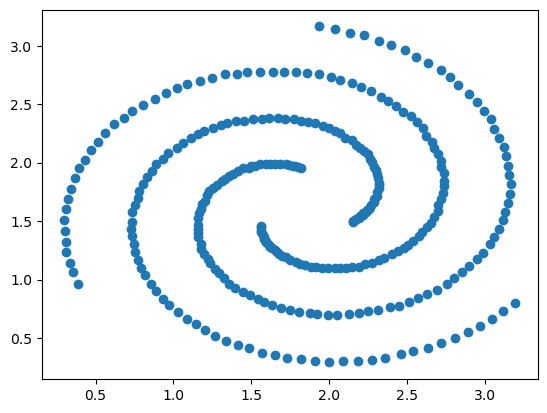

In [170]:
plt.scatter(spiral[:, 0], spiral[:, 1])

- Use sklearn kmeans to cluster points.
- Plot your results

c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


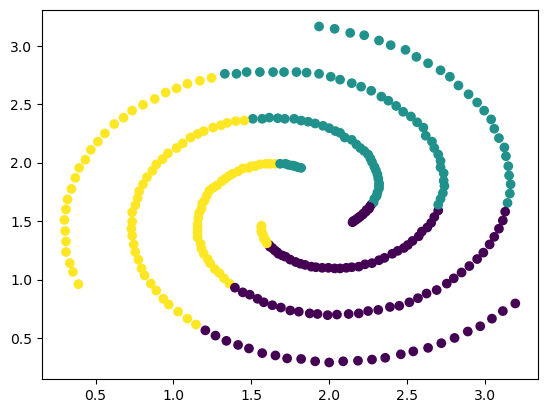

In [171]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(spiral)
plt.scatter(spiral[:, 0], spiral[:, 1], c=kmeans.labels_.astype(float))

### Question (1 point)
- Does it work? Please explain your answer, which assumptions required for kmeans? 
- What limitations do you think K-means would have?
- Can you find a k-means solution for this dataset? Write down your ideas here

Answers:
- No, it does not work.
- Limitations: K-means requires to specify the number of clusters in advance. And, it cannot tackle noisy data. Finally, it performs well for spherical and convex-shaped data, and not suitable to identify clusters with non-convex shapes.
- I found that there is a solution to solve this problem by using K-means clustering with non-convex optimization approach.

### Optional: Try your ideas to find a solution for this dataset
Keep your unsuccsessful ideas as well and try to keep your code as clean as possible

I would try spectral clustering.

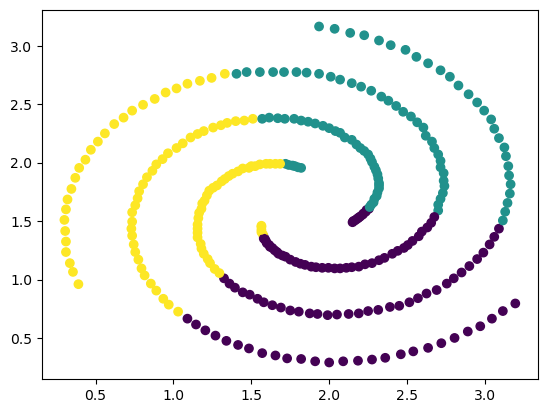

In [172]:
from sklearn.cluster import SpectralClustering

clustering = SpectralClustering(n_clusters=3, n_neighbors=10, assign_labels='discretize', random_state=0).fit(spiral)
plt.scatter(spiral[:, 0], spiral[:, 1], c=clustering.labels_.astype(float))

Ok, it doesn't work. I will try playing around with parameters, or try other algorithms such as DBSCAN. I could also try neural network.

## 2) sklearn mean-shift (3 points)

In [173]:
from sklearn.cluster import MeanShift

### 2a) Toy dataset: blobs (1 point)

- Use sklearn meanshift function to cluster points.

In [174]:
meanshift = MeanShift(bandwidth=2).fit(data_blobs)

In [175]:
meanshift.labels_

array([4, 2, 4, 0, 4, 5, 3, 0, 3, 3, 3, 1, 0, 4, 2, 0, 0, 0, 3, 0, 1, 0,
       5, 0, 0, 2, 2, 5, 1, 5, 4, 1, 2, 1, 0, 2, 3, 1, 2, 4, 4, 1, 5, 4,
       0, 3, 3, 3, 2, 3, 1, 5, 5, 1, 2, 2, 2, 2, 4, 0, 3, 0, 2, 2, 4, 4,
       3, 3, 3, 1, 5, 1, 5, 3, 1, 1, 0, 3, 3, 4, 5, 2, 3, 1, 3, 3, 0, 2,
       1, 0, 0, 2, 4, 5, 2, 1, 2, 0, 3, 4, 1, 5, 1, 1, 4, 5, 1, 5, 2, 1,
       3, 1, 1, 2, 0, 4, 2, 4, 3, 0, 3, 2, 5, 4, 5, 0, 1, 2, 4, 5, 2, 4,
       2, 0, 3, 5, 1, 0, 4, 2, 3, 4, 1, 4, 1, 2, 1, 5, 2, 3, 5, 5, 0, 4,
       1, 0, 3, 3, 0, 1, 5, 3, 4, 3, 0, 3, 4, 4, 0, 3, 3, 2, 1, 0, 1, 0,
       4, 2, 4, 2, 4, 3, 1, 5, 4, 2, 5, 4, 0, 0, 4, 2, 1, 3, 4, 4, 2, 5,
       5, 3, 2, 5, 1, 5, 3, 1, 5, 3, 2, 4, 4, 5, 0, 1, 1, 0, 1, 5, 2, 5,
       4, 1, 1, 1, 4, 3, 0, 1, 2, 0, 3, 3, 5, 5, 4, 3, 1, 3, 5, 5, 3, 2,
       3, 2, 2, 0, 1, 3, 1, 1, 1, 3, 5, 4, 0, 4, 1, 3, 4, 1, 5, 0, 0, 4,
       0, 0, 2, 1, 2, 1, 0, 5, 1, 4, 3, 3, 4, 1, 0, 2, 1, 0, 0, 2, 3, 3,
       1, 3, 1, 1, 2, 4, 0, 0, 2, 3, 2, 4, 1, 5, 2,

- Plot clustering results 

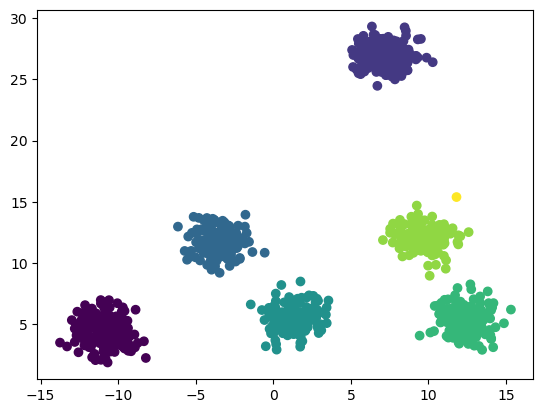

In [176]:
plt.scatter(data_blobs[:, 0], data_blobs[:, 1], c=meanshift.labels_.astype(float))

- Try different hyper-parameters (i.e. bandwidth, which is an important parameter for mean-shift) and plot the results.

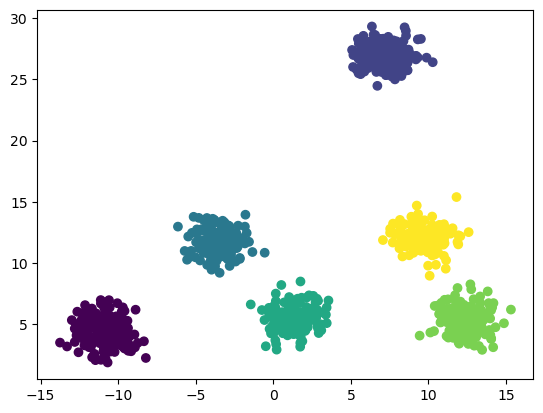

In [177]:
# Bandwidth = 3
meanshift = MeanShift(bandwidth=3).fit(data_blobs)
plt.scatter(data_blobs[:, 0], data_blobs[:, 1], c=meanshift.labels_.astype(float))

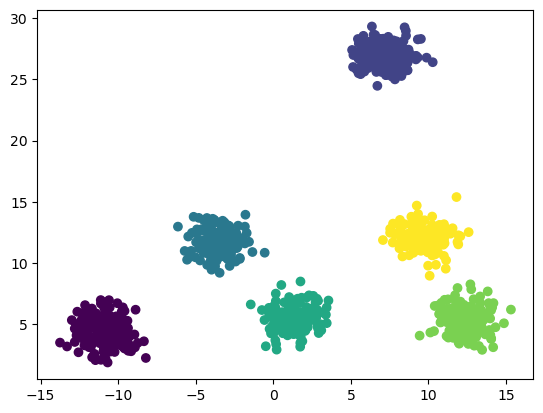

In [178]:
# Bandwidth = 4
meanshift = MeanShift(bandwidth=4).fit(data_blobs)
plt.scatter(data_blobs[:, 0], data_blobs[:, 1], c=meanshift.labels_.astype(float))

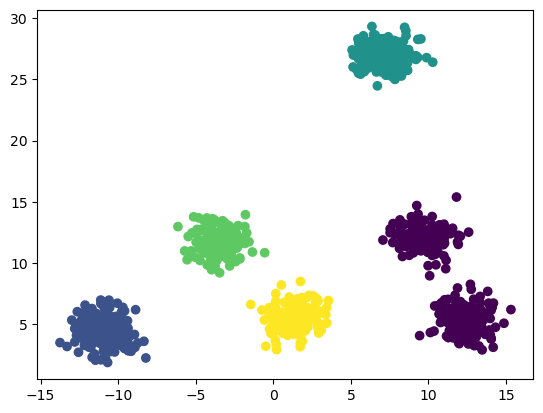

In [179]:
# Bandwidth = 5
meanshift = MeanShift(bandwidth=5).fit(data_blobs)
plt.scatter(data_blobs[:, 0], data_blobs[:, 1], c=meanshift.labels_.astype(float))

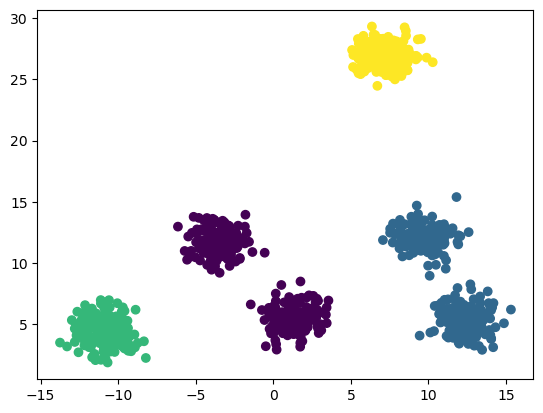

In [180]:
# Bandwidth = 6
meanshift = MeanShift(bandwidth=6).fit(data_blobs)
plt.scatter(data_blobs[:, 0], data_blobs[:, 1], c=meanshift.labels_.astype(float))

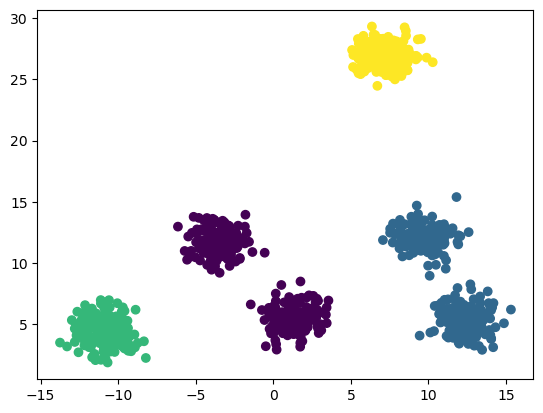

In [181]:
# Bandwidth = 7
meanshift = MeanShift(bandwidth=7).fit(data_blobs)
plt.scatter(data_blobs[:, 0], data_blobs[:, 1], c=meanshift.labels_.astype(float))

### 2b) Toy dataset: spiral (1 point)

- Use the Mean-shift to cluster the Spiral dataset.
- Plot the results.

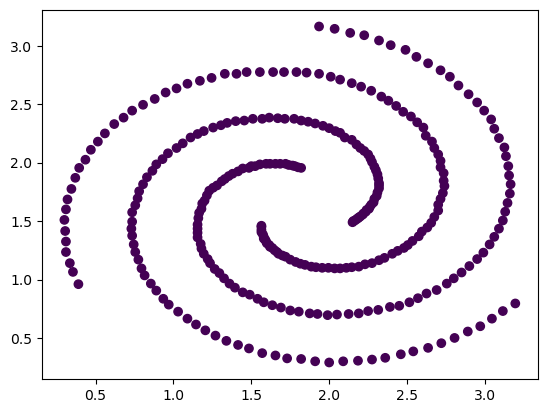

In [182]:
# Bandwidth = 2
meanshift = MeanShift(bandwidth=2).fit(spiral)
plt.scatter(spiral[:, 0], spiral[:, 1], c=meanshift.labels_.astype(float))

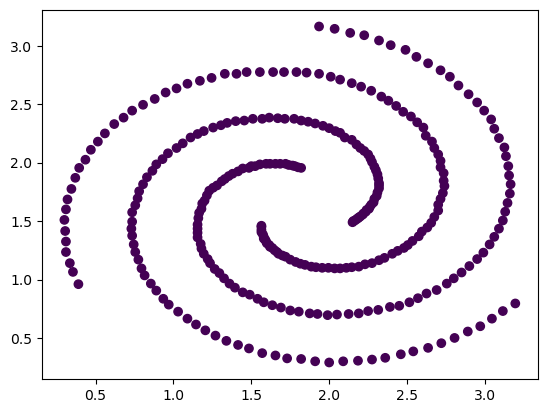

In [183]:
# Bandwidth = 3
meanshift = MeanShift(bandwidth=3).fit(spiral)
plt.scatter(spiral[:, 0], spiral[:, 1], c=meanshift.labels_.astype(float))

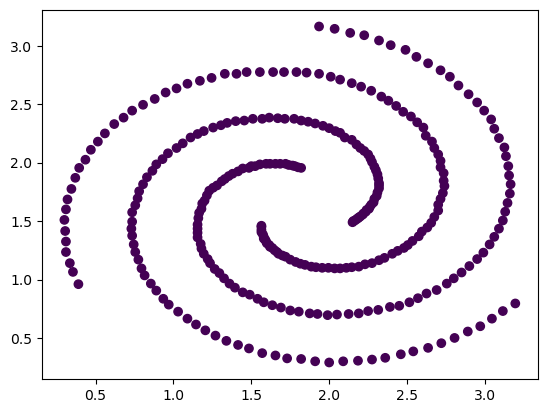

In [184]:
# Bandwidth = 4
meanshift = MeanShift(bandwidth=4).fit(spiral)
plt.scatter(spiral[:, 0], spiral[:, 1], c=meanshift.labels_.astype(float))

### Question (1 point)
- Does it work?
- What kind of data cluster is this approach better at discovering?
- Do you have a solution for this dataset? Write down what you would try

- No, it doesn't work.
- Clustered data

### Optional: Try your ideas to find a solution for this dataset
Keep your unsuccsessful ideas as well and try to keep your code as clean as possible

## Country development dataset (6 points)

country data including some socio-economic and health factors that can jointly determine the overall development of the country. We will use K-means and mean-shift methods on this dataset to make decision to choose the countries that are in the direst need of aid.

### Data Dictionary
- country = Name of the country
- child_mort = Death of children under 5 years of age per 1000 live births
- exports = Exports of goods and services. Given as %age of the Total GDP
- health = Total health spending as %age of Total GDP
- imports = Imports of goods and services. Given as %age of the Total GDP
- income = Net income per person
- inflation = The measurement of the annual growth rate of the Total GDP
- life_expec = The average number of years a new born child would live if the current mortality patterns are to remain the same
- total_fer = The number of children that would be born to each woman if the current age-fertility rates remain the same
- gdpp = The GDP per capita. Calculated as the Total GDP divided by the total population

### Data Investigation (1 point)

In [185]:
# Load data
df_country=pd.read_csv('Datasets/country_data.csv')

- Print the first few lines of your data
- Print the types of your colums
- Print the shape of your dataframe
- Print the basic statistics of the dataset

In [186]:
df_country.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [187]:
df_country.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [188]:
df_country.shape

(167, 10)

In [189]:
df_country.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


- Visualize the distribution of each feature (plot 9 figures)

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

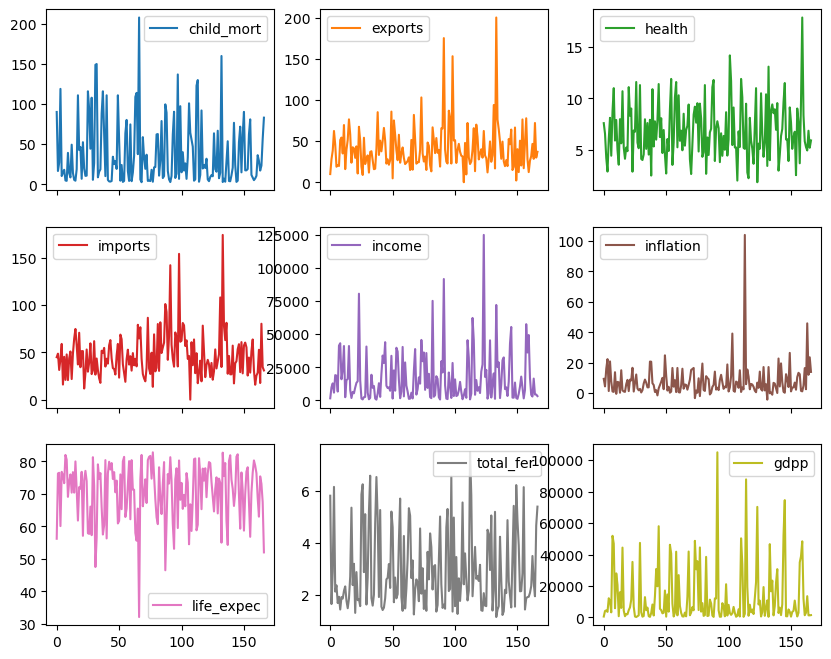

In [190]:
df_country.plot(figsize=(10,8), subplots=True, layout=(3,3))

### KMeans clustering health factors (1 point)
- Cluster the samples based on health factors(child_mort, life_expec, total_fer)
- Print the result (e.g. cluster: 0: [list of countries], cluster 1:[list of countries] ...)
- Don't forget to normalise your data
- Use the provided visualise functon to plot a 3d graph of your resulsts

In [191]:
# Make sure that all data in dataframe is numeric
df_health_factor = df_country[['child_mort', 'life_expec', 'total_fer']]
mat = df_health_factor.values

In [192]:
# Normalize the data
sc = StandardScaler()
X = sc.fit_transform(mat)

In [193]:
# Determine number of countries
num_countries = len(df_country['country'])

In [194]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(X)

c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [195]:
kmeans.labels_

array([1, 2, 2, 1, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 1, 0, 0, 2, 0,
       2, 2, 2, 1, 1, 0, 1, 2, 2, 1, 1, 2, 2, 2, 1, 1, 1, 2, 1, 2, 2, 2,
       2, 2, 2, 0, 2, 1, 0, 2, 0, 2, 2, 0, 1, 2, 2, 0, 2, 2, 0, 1, 1, 0,
       1, 2, 2, 0, 0, 2, 0, 2, 2, 2, 2, 2, 2, 0, 0, 0, 2, 0, 0, 2, 2, 1,
       1, 2, 2, 2, 2, 0, 1, 2, 2, 1, 2, 1, 2, 0, 2, 0, 2, 2, 1, 0, 0, 0,
       2, 2, 1, 1, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 2, 1, 2, 2,
       1, 2, 2, 2, 0, 0, 2, 2, 2, 2, 1, 0, 2, 2, 0, 1, 2, 1, 1, 0, 2, 2,
       0, 1, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 1])

In [196]:
# Print results (countries) of each cluster
# Cluster 0
df_country[kmeans.labels_==0]['country']

9                 Azerbaijan
12                Bangladesh
18                    Bhutan
19                   Bolivia
21                  Botswana
27                  Cambodia
47                     Egypt
50                   Eritrea
52                      Fiji
55                     Gabon
59                     Ghana
62                 Guatemala
65                    Guyana
69                     India
70                 Indonesia
72                      Iraq
79                Kazakhstan
80                     Kenya
81                  Kiribati
83           Kyrgyz Republic
84                       Lao
93                Madagascar
101    Micronesia, Fed. Sts.
103                 Mongolia
107                  Myanmar
108                  Namibia
109                    Nepal
116                 Pakistan
120              Philippines
126                   Rwanda
127                    Samoa
136          Solomon Islands
137             South Africa
143                 Suriname
146           

In [197]:
# Cluster 1
df_country[kmeans.labels_==1]['country']

0                   Afghanistan
3                        Angola
17                        Benin
25                 Burkina Faso
26                      Burundi
28                     Cameroon
31     Central African Republic
32                         Chad
36                      Comoros
37             Congo, Dem. Rep.
38                  Congo, Rep.
40                Cote d'Ivoire
49            Equatorial Guinea
56                       Gambia
63                       Guinea
64                Guinea-Bissau
66                        Haiti
87                      Lesotho
88                      Liberia
94                       Malawi
97                         Mali
99                   Mauritania
106                  Mozambique
112                       Niger
113                     Nigeria
129                     Senegal
132                Sierra Leone
142                       Sudan
147                    Tanzania
149                 Timor-Leste
150                        Togo
155     

In [198]:
# Cluster 2
df_country[kmeans.labels_==2]['country']

1                  Albania
2                  Algeria
4      Antigua and Barbuda
5                Argentina
6                  Armenia
              ...         
158         United Kingdom
159          United States
160                Uruguay
163              Venezuela
164                Vietnam
Name: country, Length: 94, dtype: object

In [199]:
def visualise(data, idx):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(data.values[:,0],data.values[:,1],data.values[:,2],marker='.', c=idx)
    ax.set_xlabel(data.columns[0])
    ax.set_ylabel(data.columns[1])
    ax.set_zlabel(data.columns[2])  
    plt.show()

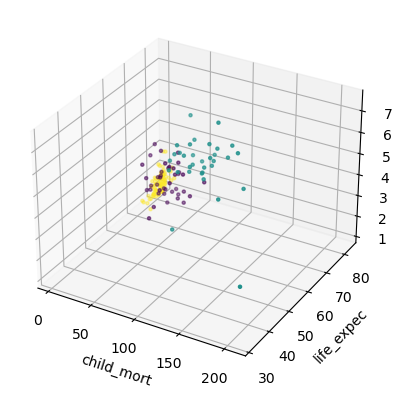

In [200]:
X_health = df_health_factor
y_kmeans_health = kmeans.labels_
visualise(X_health, y_kmeans_health)

### Cluster based on economic attributes (0.5 points)
- Cluster the samples based on economic factors('income', 'gdpp', 'health')
- Print the result (e.g. cluster: 0: [list of countries], cluster 1:[list of countries] ...)
- Don't forget to normalise your data
- Use the provided visualise functon to plot a 3d graph of your resulsts

In [201]:
# Make sure that all data in dataframe is numeric
df_economic = df_country[['income', 'gdpp', 'health']]
mat = df_economic.values

# Normalize the data
sc = StandardScaler()
X = sc.fit_transform(mat)

# Determine number of countries
num_countries = len(df_country['country'])

kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(X)

c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [202]:
# Cluster 0
df_country[kmeans.labels_==0]['country']

0              Afghanistan
1                  Albania
2                  Algeria
3                   Angola
4      Antigua and Barbuda
              ...         
162                Vanuatu
163              Venezuela
164                Vietnam
165                  Yemen
166                 Zambia
Name: country, Length: 134, dtype: object

In [203]:
# Cluster 1
df_country[kmeans.labels_==1]['country']

23                   Brunei
82                   Kuwait
91               Luxembourg
114                  Norway
123                   Qatar
133               Singapore
157    United Arab Emirates
Name: country, dtype: object

In [204]:
# Cluster 2
df_country[kmeans.labels_==2]['country']

7           Australia
8             Austria
10            Bahamas
15            Belgium
29             Canada
42             Cyprus
44            Denmark
53            Finland
54             France
58            Germany
60             Greece
68            Iceland
73            Ireland
74             Israel
75              Italy
77              Japan
98              Malta
110       Netherlands
111       New Zealand
122          Portugal
135          Slovenia
139             Spain
144            Sweden
145       Switzerland
158    United Kingdom
159     United States
Name: country, dtype: object

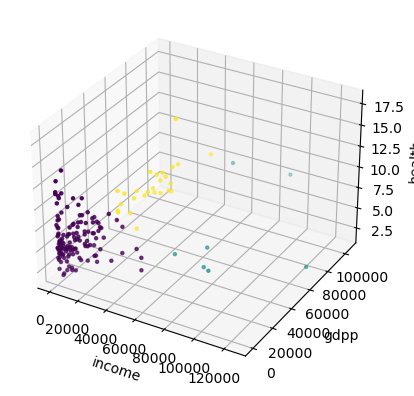

In [205]:
X_eco = df_economic
y_kmeans_eco = kmeans.labels_
visualise(X_eco, y_kmeans_eco)

### Cluster KMeans based on all attributes (0.5 points)
- Cluster the samples based on all attributes
- Print the result (e.g. cluster: 0: [list of countries], cluster 1:[list of countries] ...)
- Don't forget to normalise your data

In [206]:
# Make sure that all data in dataframe is numeric
df_all = df_country.drop('country', axis=1)
mat = df_all.values

# Normalize the data
sc = StandardScaler()
X = sc.fit_transform(mat)

# Determine number of countries
num_countries = len(df_country['country'])

kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(X)

c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [207]:
# Cluster 0
df_country[kmeans.labels_==0]['country']

1                  Albania
2                  Algeria
4      Antigua and Barbuda
5                Argentina
6                  Armenia
              ...         
160                Uruguay
161             Uzbekistan
162                Vanuatu
163              Venezuela
164                Vietnam
Name: country, Length: 86, dtype: object

In [208]:
# Cluster 1
df_country[kmeans.labels_==1]['country']

7                 Australia
8                   Austria
11                  Bahrain
15                  Belgium
23                   Brunei
29                   Canada
42                   Cyprus
43           Czech Republic
44                  Denmark
53                  Finland
54                   France
58                  Germany
60                   Greece
68                  Iceland
73                  Ireland
74                   Israel
75                    Italy
77                    Japan
82                   Kuwait
91               Luxembourg
98                    Malta
110             Netherlands
111             New Zealand
114                  Norway
122                Portugal
123                   Qatar
133               Singapore
134         Slovak Republic
135                Slovenia
138             South Korea
139                   Spain
144                  Sweden
145             Switzerland
157    United Arab Emirates
158          United Kingdom
159           United

In [209]:
# Cluster 2
df_country[kmeans.labels_==2]['country']

0                   Afghanistan
3                        Angola
17                        Benin
25                 Burkina Faso
26                      Burundi
28                     Cameroon
31     Central African Republic
32                         Chad
36                      Comoros
37             Congo, Dem. Rep.
38                  Congo, Rep.
40                Cote d'Ivoire
49            Equatorial Guinea
50                      Eritrea
55                        Gabon
56                       Gambia
59                        Ghana
63                       Guinea
64                Guinea-Bissau
66                        Haiti
80                        Kenya
81                     Kiribati
84                          Lao
87                      Lesotho
88                      Liberia
93                   Madagascar
94                       Malawi
97                         Mali
99                   Mauritania
106                  Mozambique
108                     Namibia
112     

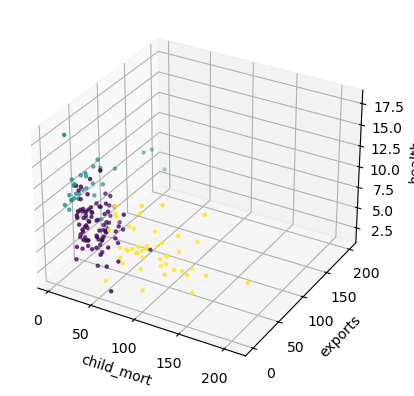

In [210]:
X_all = df_all
y_kmeans_all = kmeans.labels_
visualise(X_all, y_kmeans_all)

### Question:  (1 point)
Which feature set would you prefere and why? Do you think k-means clustering works well for this dataset?

- I would use economic attribute ('income', 'gdpp', 'health') because it gives accurate results when using 'gdpp' as reference for judging which country should be aided first.

- I think that k-means clustering algorithm works well for this data.

### Mean shift clustering (1 point)
- Cluster the samples based on all attributes using mean shift
- Print the result (e.g. cluster: 0: [list of countries], cluster 1:[list of countries] ...)
- Don't forget to normalise your data

In [211]:
# Make sure that all data in dataframe is numeric
df_all = df_country.drop('country', axis=1)
mat = df_all.values

# Normalize the data
sc = StandardScaler()
X = sc.fit_transform(mat)

# Determine number of countries
num_countries = len(df_country['country'])

meanshift = MeanShift(bandwidth=2).fit(X)

In [212]:
np.unique(meanshift.labels_)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

In [213]:
# Print list of countries for each cluster
for i in np.unique(meanshift.labels_):
    print("Cluster :", i+1)
    print(df_country[meanshift.labels_==i]['country'].values)

Cluster : 1
['Albania' 'Algeria' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Azerbaijan' 'Bahamas' 'Barbados' 'Belarus' 'Belize' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Brazil' 'Bulgaria' 'Cambodia' 'Cape Verde'
 'Chile' 'China' 'Colombia' 'Costa Rica' 'Croatia' 'Czech Republic'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Estonia' 'Fiji'
 'Georgia' 'Greece' 'Grenada' 'Guatemala' 'Guyana' 'Hungary' 'Indonesia'
 'Iran' 'Israel' 'Italy' 'Jamaica' 'Jordan' 'Kazakhstan' 'Kyrgyz Republic'
 'Latvia' 'Lebanon' 'Lithuania' 'Macedonia, FYR' 'Malaysia' 'Maldives'
 'Mauritius' 'Montenegro' 'Morocco' 'New Zealand' 'Panama' 'Paraguay'
 'Peru' 'Philippines' 'Poland' 'Portugal' 'Romania' 'Russia' 'Samoa'
 'Serbia' 'Seychelles' 'Slovak Republic' 'Slovenia' 'South Korea' 'Spain'
 'Sri Lanka' 'St. Vincent and the Grenadines' 'Suriname' 'Thailand'
 'Tonga' 'Tunisia' 'Turkey' 'Turkmenistan' 'Ukraine' 'United Kingdom'
 'Uruguay' 'Uzbekistan' 'Vietnam']
Cluster : 2
['Afghanistan' 'Banglade

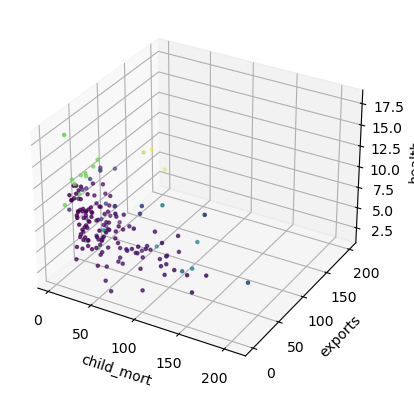

In [214]:
X_all = df_all
y_meanshift_all = meanshift.labels_
visualise(X_all, y_meanshift_all)

### Question (1 poins):
 Which method would you use to decide which countries need aid? Explain your choice and why this algorithm might worked better

I would use MeanShift because I don't need to define number of clusters at the beginning (hyperparameter-free). Therefore, the result of the prediction by MeanShift refers to the clusters (countries) that needs aid first.

## 3) Your own Mean-shift implementation (0 points)
### (Will be graded in lab 6 but is more time consuming therefore you can already start this week)

Let's implement mean-shift algorithm ourselves.

Complete the function ml_meanshift that performs the mean shift algorithm. The function takes 3 arguments:

- input data: sample points in a N-by-2 matrix (number of rows is the number of samples, dimensionality of the input data will always be 2 for this exercise)
- the kernel bandwidth $h$
- the stopping threshold $\vartheta$

It should return two values:

- cluster indexes: a column vector with N rows, specifying the cluster index for each sample
- cluster modes: a M-by-2 matrix, returning the cluster modes (the points with the highest density) for each cluster (where M is the number of clusters)

For this task, use the Epanechnikov kernel. Luckily all terms before the sum cancel out in the mean shift formula, leading to

$$
\mathbf{q}_{t+1} = \frac{
\sum_{i=1}^N \mathbf{x}_i
\max\left(0, 1 - \frac{|\mathbf{q}_t - \mathbf{x}i|^2}{h^2} \right)
} {
\sum_{i=1}^N
\max\left(0, 1 - \frac{|\mathbf{q}_t - \mathbf{x}_i|^2}{h^2} \right)
}
$$

Start the mean shift procedure at each point and iterate until $|\mathbf{q}_{t}-\mathbf{q}_{t-1}| < \vartheta$ where $\vartheta$ is the threshold passed to the function. Additionally also count the iterations and add it as condtion so the loop does not run infinitely. You can use $200$ as the maximum value of iteration.

When the iteration stopped, decide if a cluster mode already exists that is closer than $\frac{h}{5}$. If yes, assign the point that you started at to this cluster. Otherwise, create a new cluster and assign the point to the new cluster.

In [215]:
import math
from numpy import linalg as la
import numpy.matlib

In [216]:
# DO NOT MODIFY
def visualise_kmeans(data,idx,centers,updated=None):
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    ax.scatter(data[:,0],data[:,1],marker='.', c=idx)
    ax.plot(centers[:,0],centers[:,1],'+',color='r',markersize=15,mew=2)
    plt.show()
def test_meanshift():
    data = np.genfromtxt('data/toy_data.csv', delimiter=',')
    idx, centers = ml_meanshift(data,4,0.001)
    
    centers_2 = np.array(centers)
    
    visualise_kmeans(data=data,idx=idx,centers=centers_2)

In [217]:
def ml_meanshift(data,h,theta):
    # ml_meanshift returns cluster indices and modes from computed with meanshift algorithm

    # initialization
    #initialize modes
    modes = 
    #initialize index variable for data points
    index = 
    #s = number of data points
    s = 

    #take i-th element as query point
    for i in range(s):
        #initialize starting q0 and q1 condition
        q1 = 
        q0 = 

        #iteration initilization
        it = 0

        while ():
            #update break criterion values

            #update iteration
            it = it+1

        #check for clusters in the vicinity
        #1st condition: if mode is not empty
        #2nd: if a cluster mode exists closer than h/5
        #else create a new cluster

    return index, modes

SyntaxError: invalid syntax (1818772192.py, line 6)

In [ ]:
# test and visualise your results
test_meanshift()